# Day 2

Today, we will start using nf-core pipelines to find differentially abundant genes in our dataset. 
We are using data from the following paper: https://www.nature.com/articles/s41593-023-01350-3#Sec10

1. Please take some time to read through the paper and understand their approach, hypotheses and goals.

What was the objective of the study?

To investigate how chronic neuropathic pain influences the behavioral and gene-expression changes caused by oxycodone withdrawal, and whether inhibiting HDAC1/HDAC2 could reduce withdrawal-related effects

What do the conditions mean?

oxy: Oxycodone treatment followed by withdrawal (medication group)


sal: Saline (control group)

What do the genotypes mean?

SNI: Spared nerve injury (make a model of chronic neuropathic pain.)


Sham: Sham surgery (control group)

Imagine you are the bioinformatician in the group who conducted this study. They hand you the raw files and ask you to analyze them.

What would you do?
- perform quality control on the raw data 
- align the reads to mouse reference genome 
- quantify gene expression
- check sample quality using PCA
- perform differential expression analysis
- perform pathway enrichment analysis
- analyze each brain region separately

Which groups would you compare to each other?
- Sham-oxy vs. Sham-sal : expect changes in reward-related and synaptic pathways
- SNI-oxy vs. SNI-sal : expect a response that may differ from that in sham mice
- SNI-sal vs. Sham-sal : expect changes in pain-related, inflammatory, and neuronal plasticity pathways
- SNI-oxy vs. Sham-oxy: expect effects of nerve injury in the context of oxycodone exposure and withdrawal

Please also mention which outcome you would expect to see from each comparison.

Your group gave you a very suboptimal excel sheet (conditions_runs_oxy_project.xlsx) to get the information you need for each run they uploaded to the SRA.<br>
So, instead of directly diving into downloading the data and starting the analysis, you first need to sort the lazy table.<br>
Use Python and Pandas to get the table into a more sensible order.<br>
Then, perform some overview analysis and plot the results
1. How many samples do you have per condition?
2. How many samples do you have per genotype?
3. How often do you have each condition per genotype?

In [9]:
import pandas as pd
from pathlib import Path

In [10]:
files = list(Path("..").rglob("conditions_runs_oxy_project.xlsx"))
files

[PosixPath('../day_02/conditions_runs_oxy_project.xlsx')]

In [11]:
df_raw = pd.read_excel("conditions_runs_oxy_project.xlsx")
df_raw.head(10)

,Patient,Run,RNA-seq,DNA-seq,condition: Sal,Condition: Oxy,Genotype: SNI,Genotype: Sham
0,?,SRR23195505,x,NaN,x,NaN,x,NaN
1,?,SRR23195506,x,NaN,NaN,x,NaN,x
2,?,SRR23195507,x,NaN,x,NaN,NaN,x
3,?,SRR23195508,x,NaN,NaN,x,x,NaN
4,?,SRR23195509,x,NaN,NaN,x,x,NaN
5,?,SRR23195510,x,NaN,x,NaN,x,NaN
6,?,SRR23195511,x,NaN,NaN,x,NaN,x
7,?,SRR23195512,x,NaN,x,NaN,NaN,x
8,?,SRR23195513,x,NaN,x,NaN,x,NaN
9,?,SRR23195514,x,NaN,NaN,x,NaN,x


In [12]:
df_raw.columns.tolist()

['Patient',
 'Run',
 'RNA-seq',
 'DNA-seq',
 'condition: Sal',
 'Condition: Oxy',
 'Genotype: SNI',
 'Genotype: Sham']

In [17]:
df = df_raw.copy()

#merge conditions to one column
df["condition"] = pd.Series(pd.NA, index=df.index, dtype="string")

df.loc[df["condition: Sal"].eq("x"), "condition"] = "sal"
df.loc[df["Condition: Oxy"].eq("x"), "condition"] = "oxy"

df = df.drop(columns=["condition: Sal", "Condition: Oxy"])
df.head(10)

,Patient,Run,RNA-seq,DNA-seq,Genotype: SNI,Genotype: Sham,condition
0,?,SRR23195505,x,NaN,x,NaN,sal
1,?,SRR23195506,x,NaN,NaN,x,oxy
2,?,SRR23195507,x,NaN,NaN,x,sal
3,?,SRR23195508,x,NaN,x,NaN,oxy
4,?,SRR23195509,x,NaN,x,NaN,oxy
5,?,SRR23195510,x,NaN,x,NaN,sal
6,?,SRR23195511,x,NaN,NaN,x,oxy
7,?,SRR23195512,x,NaN,NaN,x,sal
8,?,SRR23195513,x,NaN,x,NaN,sal
9,?,SRR23195514,x,NaN,NaN,x,oxy


In [20]:
#merge genotypes to one column
df["genotype"] = pd.Series(pd.NA, index=df.index, dtype="string")

df.loc[df["Genotype: SNI"].eq("x"), "genotype"] = "SNI"
df.loc[df["Genotype: Sham"].eq("x"), "genotype"] = "Sham"

df = df.drop(columns=["Genotype: SNI", "Genotype: Sham"])
df.head(10)

,Patient,Run,RNA-seq,DNA-seq,condition,genotype
0,?,SRR23195505,x,NaN,sal,SNI
1,?,SRR23195506,x,NaN,oxy,Sham
2,?,SRR23195507,x,NaN,sal,Sham
3,?,SRR23195508,x,NaN,oxy,SNI
4,?,SRR23195509,x,NaN,oxy,SNI
5,?,SRR23195510,x,NaN,sal,SNI
6,?,SRR23195511,x,NaN,oxy,Sham
7,?,SRR23195512,x,NaN,sal,Sham
8,?,SRR23195513,x,NaN,sal,SNI
9,?,SRR23195514,x,NaN,oxy,Sham


In [21]:
# How many samples do you have per condition?
condition_counts = df["condition"].value_counts(dropna=False)
condition_counts

condition
sal    8
oxy    8
Name: count, dtype: Int64

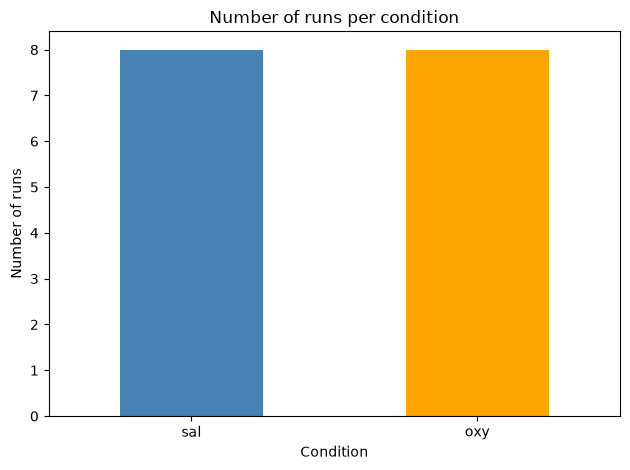

In [22]:
import matplotlib.pyplot as plt

condition_counts.plot(kind="bar", color=["steelblue", "orange"])

plt.xlabel("Condition")
plt.ylabel("Number of runs")
plt.title("Number of runs per condition")
plt.xticks(rotation=0)
plt.yticks(range(0, int(condition_counts.max()) + 1))
plt.tight_layout()
plt.show()

In [26]:
# How many samples do you have per genotype?
genotype_counts = df["genotype"].value_counts(dropna=False)
genotype_counts

genotype
SNI     8
Sham    8
Name: count, dtype: Int64

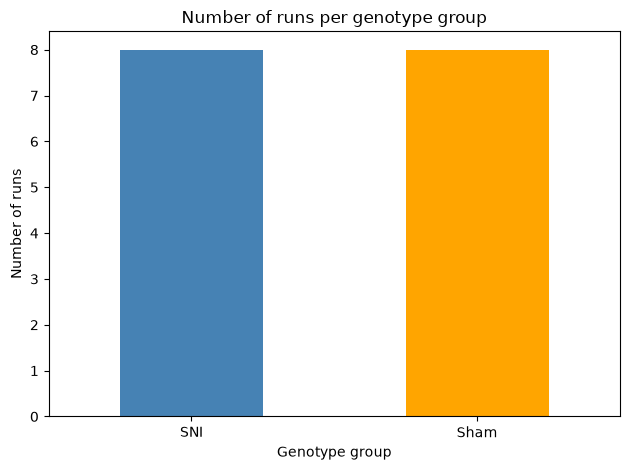

In [27]:
genotype_counts.plot(kind="bar", color=["steelblue", "orange"])

plt.xlabel("Genotype group")
plt.ylabel("Number of runs")
plt.title("Number of runs per genotype group")
plt.xticks(rotation=0)
plt.yticks(range(0, int(genotype_counts.max()) + 1))
plt.tight_layout()
plt.show()

In [28]:
# How often do you have each condition per genotype?
group_counts = pd.crosstab(df["genotype"], df["condition"])
group_counts

condition,oxy,sal
genotype,,
SNI,4,4
Sham,4,4


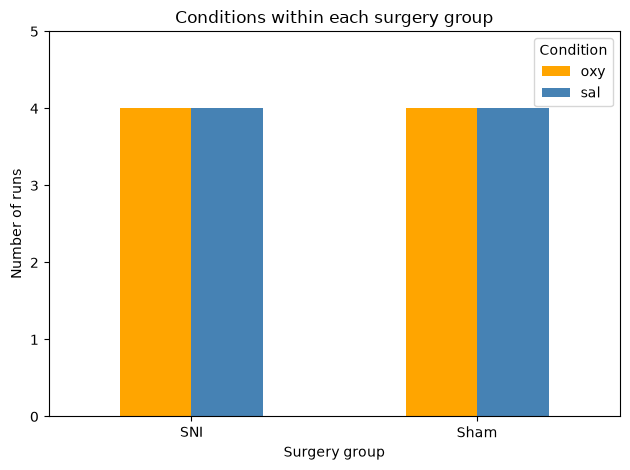

In [29]:
group_counts.plot(kind="bar", color=["orange", "steelblue"])

plt.xlabel("Surgery group")
plt.ylabel("Number of runs")
plt.title("Conditions within each surgery group")
plt.xticks(rotation=0)
plt.yticks(range(0, 6))
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

There are 16 runs in total: 8 per condition (sal and oxy) and 8 per surgery group (SNI and Sham). Each combination contains 4 runs, giving a balanced 2 × 2 design at the run level.

They were so kind to also provide you with the information of the number of bases per run, so that you can know how much space the data will take on your Cluster.<br>
Add a new column to your fancy table with this information (base_counts.csv) and sort your dataframe according to this information and the condition.

Then select the 2 smallest runs from your dataset and download them from SRA (maybe an nf-core pipeline can help here?...)

In [30]:
base_counts = pd.read_csv("base_counts.csv")
base_counts.head()

,Run,Bases
0,SRR23195505,6922564500
1,SRR23195506,7859530800
2,SRR23195507,8063298900
3,SRR23195508,6927786900
4,SRR23195509,7003550100


In [33]:
# merge
df = df.merge(
    base_counts[["Run", "Bases"]],
    on="Run",
    how="left",
    validate="one_to_one"
)

df[["Run", "condition", "genotype", "Bases"]].head()


,Run,condition,genotype,Bases
0,SRR23195505,sal,SNI,6922564500
1,SRR23195506,oxy,Sham,7859530800
2,SRR23195507,sal,Sham,8063298900
3,SRR23195508,oxy,SNI,6927786900
4,SRR23195509,oxy,SNI,7003550100


In [36]:
# sort
df["Bases"] = pd.to_numeric(df["Bases"], errors="raise")

df_sorted = df.sort_values(
    by=["Bases", "condition"],
    ascending=True
).reset_index(drop=True)

df_sorted[["Run", "condition", "genotype", "Bases"]]

,Run,condition,genotype,Bases
0,SRR23195516,oxy,SNI,6203117700
1,SRR23195511,oxy,Sham,6456390900
2,SRR23195517,oxy,SNI,6863840400
3,SRR23195505,sal,SNI,6922564500
4,SRR23195508,oxy,SNI,6927786900
5,SRR23195519,oxy,Sham,6996050100
6,SRR23195509,oxy,SNI,7003550100
7,SRR23195514,oxy,Sham,7226808600
8,SRR23195510,sal,SNI,7377388500
9,SRR23195512,sal,Sham,7462857900


In [39]:
# choose the 2 smallest runs
smallest_runs = df_sorted.head(2).copy()
smallest_runs[["Run", "condition", "genotype", "Bases"]]

,Run,condition,genotype,Bases
0,SRR23195516,oxy,SNI,6203117700
1,SRR23195511,oxy,Sham,6456390900


In [ ]:

smallest_runs["Run"].to_csv(
    "accessions.txt",
    index=False,
    header=False
)

In [40]:
smallest_runs.to_csv("selected_runs_metadata.csv", index=False)

In [ ]:
#download using (.txt not acceptable)： 
#nextflow run nf-core/fetchngs \
#  -r 1.13.0 \
#  -profile docker \
#  --input accessions.csv \
#  --outdir fetchngs_results

While your files are downloading, get back to the paper and explain how you would try to reproduce the analysis.<br>
When you are done with this shout, so we can discuss the different ideas.

- obtain the raw sequencing data and sample metadata: treatment, surgery group, brain region and batch info.
- use nf-core/fetchings to download the reads
- use nf-core/rnaseq for qc, alignment and gene-level quantification
- inspect qc reports and PCA plots
- analyze each brain region through nf-core/differentialabundance: compare the treatment and surgery groups and test their interaction
- compare differential expression patterns, enrichment pathways and key findings with the paper